<a href="https://colab.research.google.com/github/Bidisha314/Langflow-Job_search_agent/blob/main/Job_Search_Agent_in_Langflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **How to build a Job_Search_Agent in Langflow**
A self-hosted automation workflow built using Langflow, Docker Desktop, and Pinggy that scans job portals, analyzes resumes using AI, and sends real-time job alerts directly to Discord.

Access the system from anywhere and automate job discovery with a customizable, end-to-end AI workflow.

**Refernces:**
*   [Github Langflow](https://github.com/langflow-ai/langflow)
*   [Langflow's Documentation](https://docs.langflow.org/)
*   [How to Self-Host Langflow and Access It Remotely](https://pinggy.io/blog/self_host_langflow_and_access_remotely/)
*   [Tutorial: Remotely run Langflow](https://youtu.be/TvB37TSWujg?si=m7h8BE3F4CerpybJ)



## **Pull langflow with Docker:**

In [ ]:
docker pull langflowai/langflow:latest

## **Start a Langflow container with default settings:**

In [ ]:
docker run -p 7860:7860 langflowai/langflow:latest

Run Langflow with persistent storage:

In [ ]:
docker run -d \
  -p 7860:7860 \
  -v langflow_data:/app/langflow \
  --name langflow \
  langflowai/langflow:latest

### **How to build a Job_Search_Agent Step by step**

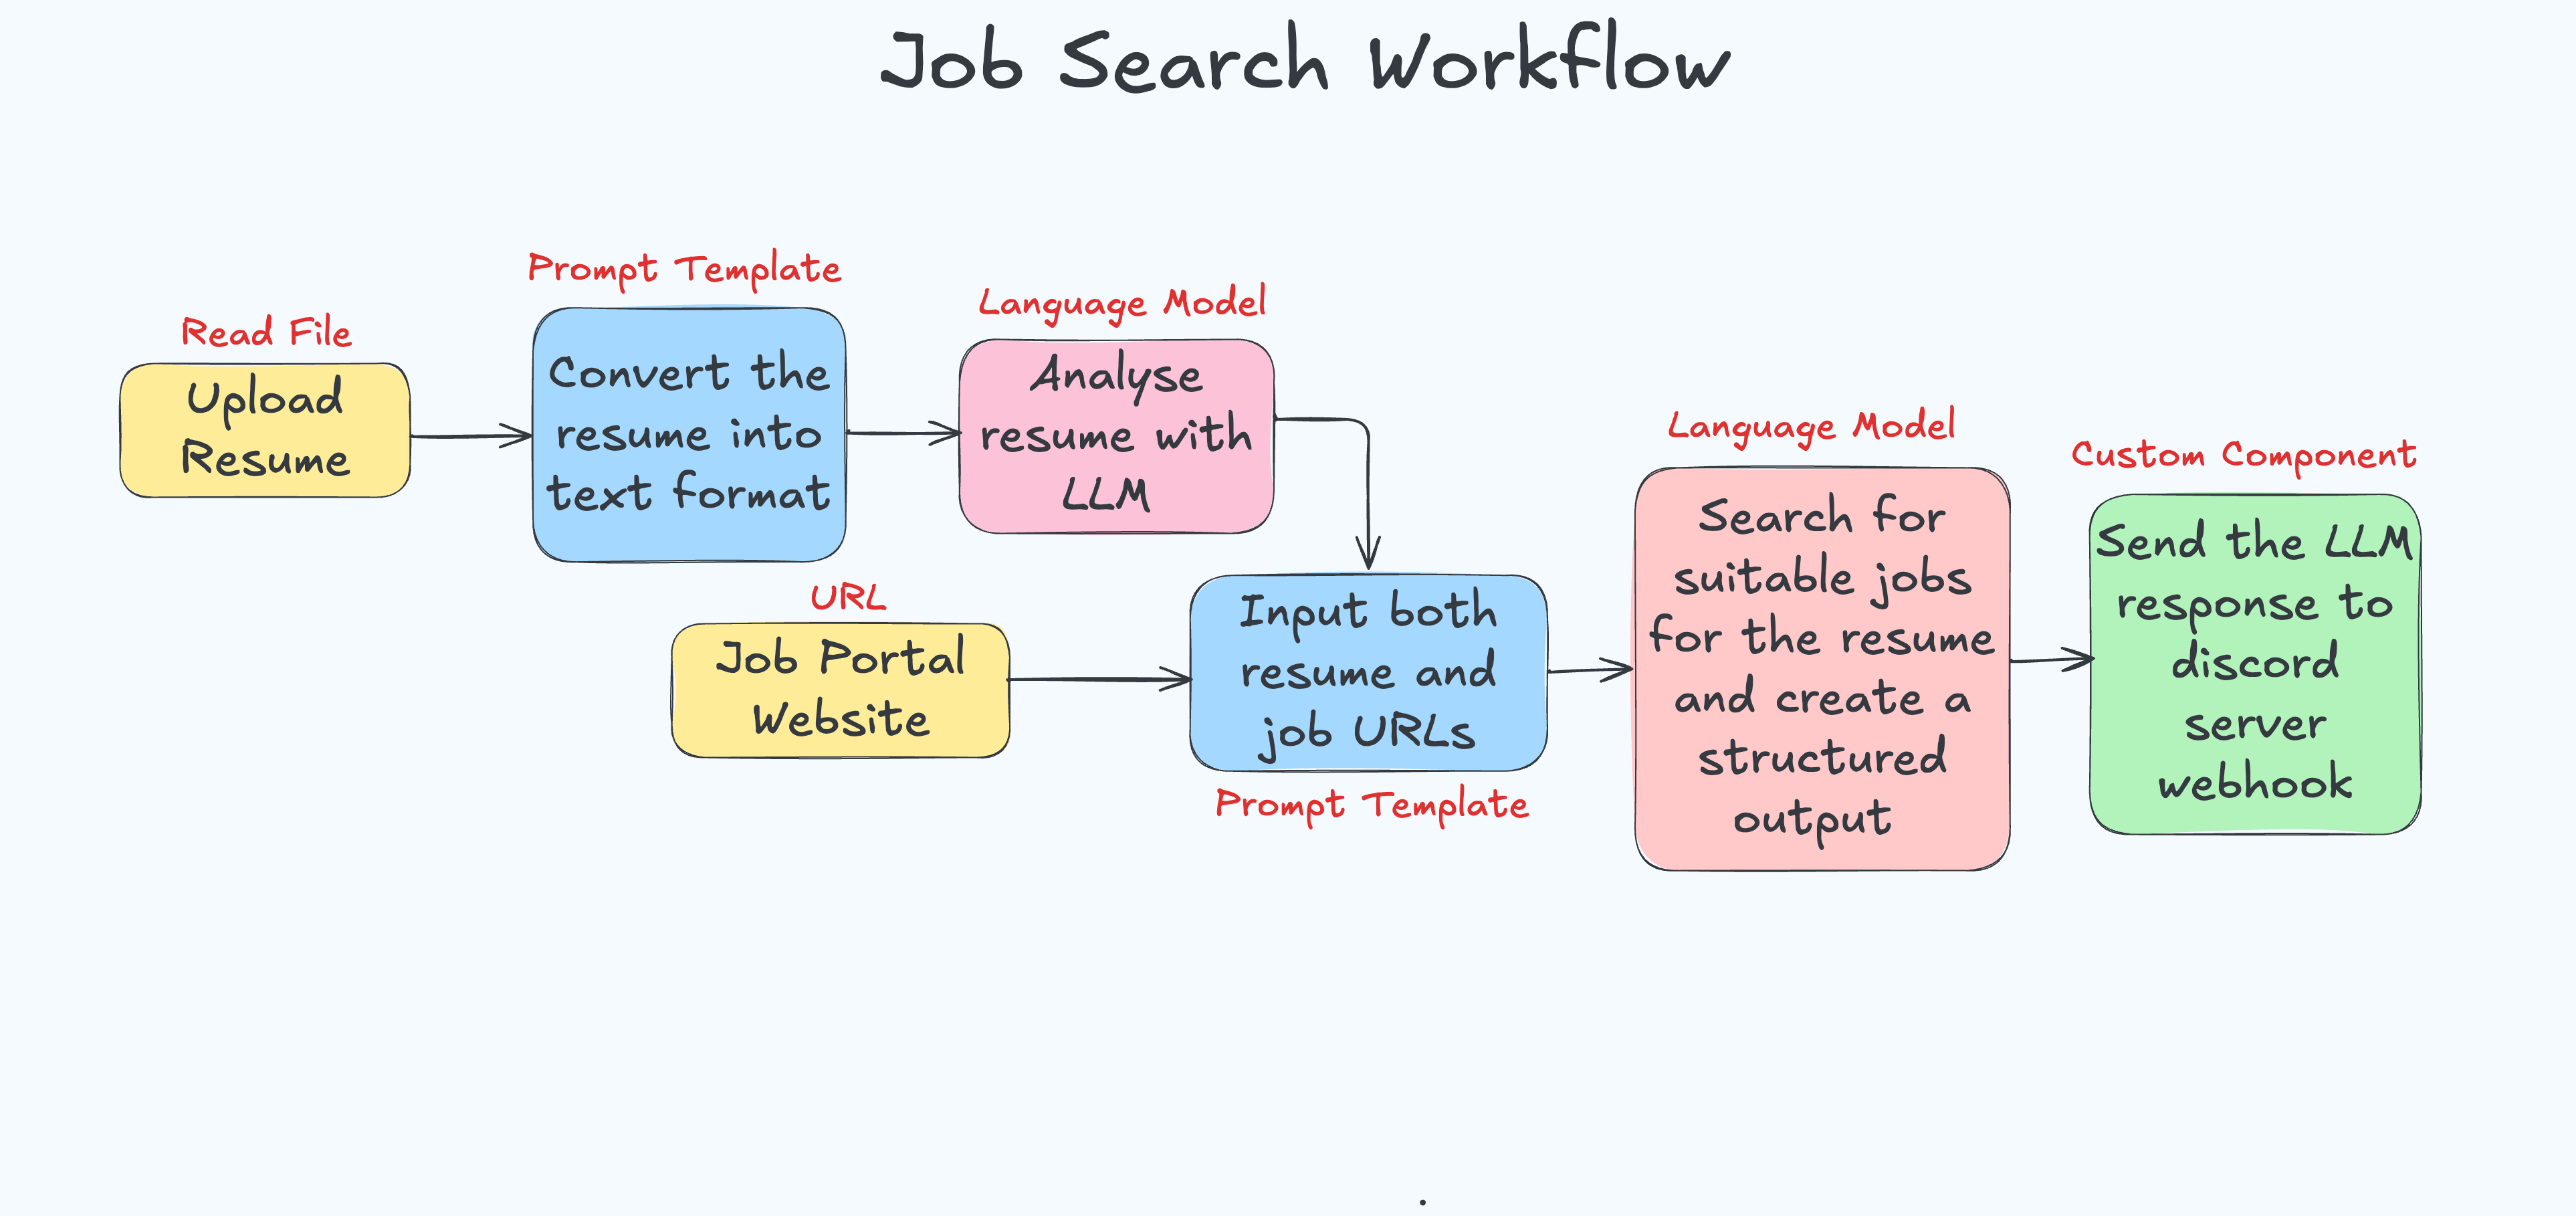

## Prompt Template 1

In [ ]:
You are an AI job assistant.

Analyze the candidate resume and extract structured information.

Return ONLY valid JSON.

Fields:
- skills
- preferred_job_roles
- experience_level
- location_preference

Resume:
{text}

Return format:

{{
 "skills": [],
 "preferred_job_roles": [],
 "experience_level": "",
 "location_preference": ""
}}


## URL Used:
*  https://remoteok.com/remote-dev-jobs
*  https://www.workingnomads.com/jobs
*  https://www.python.org/jobs/
*  https://remoteok.com/remote-ai-jobs
*  https://europeremotely.com/remote-jobs



## Prompt Template 2

In [ ]:
You are an AI job search assistant.

Candidate profile:
{resume}

Job board content:
{jobs}

Your task:
1. Extract jobs that match the candidate profile.
2. For each job, ALWAYS extract the application link if present.
3. The application link may appear as:
   - "Apply"
   - "Apply here"
   - "Read more"
   - "View job"
   - a URL (http/https)

Rules:
- If a URL is found near a job, use it as the application_link.
- If multiple links exist, choose the most relevant job application link.

IMPORTANT:
- If no application link is found, DO NOT return "Not available".
- Instead, generate a fallback Google search link using:
  job title + company name.

Format:
https://www.google.com/search?q=JOB_TITLE+COMPANY+apply

Return ONLY valid JSON.

Return format:

{{
 "jobs":[
  {{
   "company":"",
   "job_title":"",
   "location":"",
   "experience":"",
   "job_post_date":"",
   "application_deadline":"",
   "job_description_summary":"",
   "application_link":""
  }}
 ]
}}


## Language Model 2: Prompt

In [ ]:
You are a Discord webhook caller. Your ONLY job is to output a valid raw JSON string and nothing else. No explanation, no markdown, no codeblocks.
Always output exactly this format:
{"content:" "<job listings here>"}
Keep content under 1900 characters. Format jobs as plain text like:
1. Company|Title|Location|Application_link


## New Custom Component->Discord Notifier

In [ ]:
from lfx.custom.custom_component.component import Component
from lfx.io import MessageTextInput, Output
from lfx.schema import Data
import urllib.request
import json

class DiscordNotifier(Component):
    display_name = "Discord Notifier"
    description = "Sends a message to Discord webhook"
    icon = "send"

    inputs = [
        MessageTextInput(
            name="message",
            display_name="Message",
            tool_mode=True,
        ),
    ]

    outputs = [
        Output(display_name="Result", name="result", method="send_to_discord")
    ]

    def send_to_discord(self) -> Data:
        webhook_url = "Discord_Server_Webhook_URL" #Use your server's URL

        raw = str(self.message)

        # Extract the content value from {"content": "..."}
        try:
            parsed = json.loads(raw)
            text = parsed.get("content", raw)
        except Exception:
            text = raw

        # Format each line nicely with emojis
        lines = ["📋 **New Job Listings**\n"]
        for line in text.strip().split("\n"):
            if not line.strip():
                continue
            parts = line.split("|")
            if len(parts) >= 4:
                number_company = parts[0].strip()  # "1. DivIHN Integration Inc"
                title          = parts[1].strip()
                location       = parts[2].strip()
                link           = parts[3].strip()

                lines.append(
                    f"**{number_company}. {title}**\n"
                    f"📍 {location}\n"
                    f"🔗 {link}\n"
                )
            else:
                lines.append(line)

        msg = "\n".join(lines)[:1990]

        payload = json.dumps({"content": msg}).encode()
        req = urllib.request.Request(
            webhook_url,
            data=payload,
            headers={
                "Content-Type": "application/json",
                "User-Agent": "DiscordBot (https://github.com, 1.0)"
            },
            method="POST"
        )
        urllib.request.urlopen(req)
        self.status = "Sent!"
        return Data(data={"status": "success"})



## Self-host Langflow with Pinggy
Just run this single command to your terminal and get a public URL instantly.

Check:[ Pinggy.io](https://pinggy.io/)

**For Free Tunnel:**

In [ ]:
ssh -p 443 -R0:localhost:7860 qr@free.pinggy.io

**Use Pinggy Pro:**

In [ ]:
ssh -p 443 -R0:localhost:7860 -L4300:localhost:4300 -o StrictHostKeyChecking=no -o ServerAliveInterval=30 [Pinggy_token]@pro.pinggy.io